# Notebook 5: Interpretation, Health Advisory Logic & Ethical Analysis
## Real-Time Air Quality Monitoring Agent

**Purpose:** This final notebook implements the health advisory agent, interprets
model results in plain language, and critically examines societal and ethical
implications of the AI system.

**Prerequisites:** All previous notebooks (01–04) must be run first.

**Key output:** A fully functional `AQIAdvisoryAgent` class that accepts real-time
sensor readings and returns personalised health recommendations.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# dataclasses provides a clean way to define structured data objects in Python.
# joblib loads the trained models saved in Notebook 3.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load trained models from Notebook 3
#
# The models were serialised with joblib.dump().  Loading them here avoids
# retraining and ensures we use exactly the same parameters.
# ─────────────────────────────────────────────────────────────────────────────
rf_regr  = joblib.load('models/rf_regressor.pkl')
rf_clf   = joblib.load('models/rf_classifier.pkl')
scaler   = joblib.load('models/scaler.pkl')

print('✅ Models loaded')

✅ Models loaded


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Health Advisory Knowledge Base
#
# This dictionary encodes domain knowledge from WHO, CPCB, and public health
# guidelines.  Each AQI category maps to:
#   - color_hex      : CPCB official colour for the category
#   - general_advice : guidance for the general population
#   - sensitive_advice: stricter guidance for sensitive groups
#                       (children, elderly, respiratory/cardiac patients)
#   - outdoor_activity: whether outdoor activity is recommended
#   - mask_required  : whether a mask is advisable
# ─────────────────────────────────────────────────────────────────────────────
HEALTH_ADVISORY_DB = {
    'Good': {
        'color_hex'        : '#00e400',
        'general_advice'   : 'Air quality is ideal. Enjoy outdoor activities freely.',
        'sensitive_advice' : 'Safe for all groups. Normal activity is fine.',
        'outdoor_activity' : 'Recommended',
        'mask_required'    : False,
        'window_open'      : True,
        'exercise_outdoor' : True,
    },
    'Satisfactory': {
        'color_hex'        : '#92d050',
        'general_advice'   : 'Air quality is acceptable. Minor discomfort for very sensitive individuals.',
        'sensitive_advice' : 'Highly sensitive people should limit prolonged outdoor exertion.',
        'outdoor_activity' : 'Mostly recommended',
        'mask_required'    : False,
        'window_open'      : True,
        'exercise_outdoor' : True,
    },
    'Moderate': {
        'color_hex'        : '#ffff00',
        'general_advice'   : 'Sensitive individuals may experience health effects. Reduce prolonged outdoor exertion.',
        'sensitive_advice' : 'Limit outdoor activities. Stay indoors during peak pollution hours (morning/evening).',
        'outdoor_activity' : 'Reduce',
        'mask_required'    : True,
        'window_open'      : False,
        'exercise_outdoor' : False,
    },
    'Poor': {
        'color_hex'        : '#ff7e00',
        'general_advice'   : 'Everyone may begin to experience health effects. Avoid prolonged outdoor activity.',
        'sensitive_advice' : 'Stay indoors. Use N95 masks if outdoors. Keep windows closed.',
        'outdoor_activity' : 'Avoid',
        'mask_required'    : True,
        'window_open'      : False,
        'exercise_outdoor' : False,
    },
    'Very Poor': {
        'color_hex'        : '#ff0000',
        'general_advice'   : 'Serious health effects for everyone. Avoid all outdoor activities.',
        'sensitive_advice' : 'Avoid going outdoors. Consult a doctor if experiencing respiratory symptoms.',
        'outdoor_activity' : 'Avoid completely',
        'mask_required'    : True,
        'window_open'      : False,
        'exercise_outdoor' : False,
    },
    'Severe': {
        'color_hex'        : '#7e0023',
        'general_advice'   : 'Health emergency. Stay indoors. Use air purifier. Seek medical attention if unwell.',
        'sensitive_advice' : 'Do NOT go outdoors. Wear N95 indoors if purifier unavailable. Call emergency services if needed.',
        'outdoor_activity' : 'EMERGENCY — Do not go outdoors',
        'mask_required'    : True,
        'window_open'      : False,
        'exercise_outdoor' : False,
    }
}

print('✅ Health advisory knowledge base defined')
print(f'   Categories covered: {list(HEALTH_ADVISORY_DB.keys())}')

✅ Health advisory knowledge base defined
   Categories covered: ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — AQI Advisory Agent Class
#
# This class encapsulates the entire advisory pipeline:
#   1. accept_readings()  → ingest raw sensor data
#   2. preprocess()       → compute derived features
#   3. predict_aqi()      → call the Random Forest model
#   4. get_advisory()     → look up health guidance for the predicted category
#   5. generate_report()  → format a human-readable advisory report
# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class SensorReading:
    """
    Holds a single set of pollutant sensor readings.
    All concentrations are in µg/m³ unless noted.
    """
    city     : str
    pm25     : float   # Fine particulate matter
    pm10     : float   # Coarse particulate matter
    no       : float   # Nitric oxide
    no2      : float   # Nitrogen dioxide
    nox      : float   # Nitrogen oxides total
    nh3      : float   # Ammonia
    co       : float   # Carbon monoxide (mg/m³)
    so2      : float   # Sulphur dioxide
    o3       : float   # Ozone
    benzene  : float = 0.0
    toluene  : float = 0.0
    xylene   : float = 0.0
    timestamp: str = field(default_factory=lambda: datetime.now().isoformat())
    is_sensitive_group: bool = False  # True for children/elderly/patients


class AQIAdvisoryAgent:
    """
    AI agent that accepts real-time sensor readings and produces
    AQI predictions with personalised health advisories.
    """

    # AQI category breakpoints (CPCB)
    CATEGORY_THRESHOLDS = {
        'Good':          (0,   50),
        'Satisfactory':  (51,  100),
        'Moderate':      (101, 200),
        'Poor':          (201, 300),
        'Very Poor':     (301, 400),
        'Severe':        (401, 500),
    }

    # City-to-encoded-integer mapping (must match Notebook 1)
    CITY_CODES = {
        'Ahmedabad': 0, 'Bengaluru': 1, 'Chennai': 2, 'Delhi': 3,
        'Hyderabad': 4, 'Jaipur': 5, 'Kolkata': 6, 'Lucknow': 7,
        'Mumbai': 8, 'Pune': 9
    }

    def __init__(self, regressor, classifier):
        """
        Initialise the agent with pre-trained sklearn models.
        regressor  : RF model that predicts numeric AQI
        classifier : RF model that predicts AQI category code
        """
        self.regressor  = regressor
        self.classifier = classifier

    def _compute_features(self, r: SensorReading) -> np.ndarray:
        """Convert a SensorReading into the 26-feature vector the model expects."""
        EPSILON = 1e-6
        ts  = pd.Timestamp(r.timestamp)
        month = ts.month
        dow   = ts.dayofweek

        # Composite pollution index (same formula as Notebook 2)
        pollution_index = (
            0.35 * min(r.pm25, 500) / 500 +
            0.20 * min(r.pm10, 600) / 600 +
            0.15 * min(r.no2, 200)  / 200 +
            0.15 * min(r.so2, 100)  / 100 +
            0.10 * min(r.o3, 200)   / 200 +
            0.05 * min(r.co, 20)    / 20
        )

        features = [
            r.pm25, r.pm10, r.no, r.no2, r.nox, r.nh3, r.co, r.so2, r.o3,
            r.benzene, r.toluene, r.xylene,
            r.no2 / (r.nox + EPSILON),   # NO2/NOx ratio
            r.pm25 / (r.pm10 + EPSILON), # PM2.5/PM10 ratio
            r.so2  / (r.no2  + EPSILON), # SO2/NO2 ratio
            pollution_index,
            np.sin(2 * np.pi * month / 12),  # Month cyclical encoding
            np.cos(2 * np.pi * month / 12),
            np.sin(2 * np.pi * dow   / 7),   # Day-of-week cyclical
            np.cos(2 * np.pi * dow   / 7),
            0.0,  # AQI_rolling_mean_7d  (not available in real-time; use 0)
            0.0,  # AQI_rolling_mean_30d
            0.0,  # AQI_change
            self.CITY_CODES.get(r.city, 3),  # city code (default Delhi)
            1,    # Season_enc placeholder
            ts.year,
        ]
        return np.array(features, dtype=float).reshape(1, -1)

    def _numeric_to_category(self, aqi: float) -> str:
        """Convert a numeric AQI to its CPCB descriptive category."""
        for cat, (lo, hi) in self.CATEGORY_THRESHOLDS.items():
            if lo <= aqi <= hi:
                return cat
        return 'Severe'

    def predict(self, reading: SensorReading) -> Dict:
        """
        Main pipeline: compute features → predict AQI → generate advisory.
        Returns a dictionary with predicted values and health guidance.
        """
        X     = self._compute_features(reading)
        aqi   = float(self.regressor.predict(X)[0])
        cat   = self._numeric_to_category(aqi)
        advice = HEALTH_ADVISORY_DB[cat]

        # Select general or sensitive-group advisory
        guidance = (advice['sensitive_advice']
                    if reading.is_sensitive_group
                    else advice['general_advice'])

        return {
            'city'            : reading.city,
            'timestamp'       : reading.timestamp,
            'aqi_predicted'   : round(aqi, 1),
            'category'        : cat,
            'color'           : advice['color_hex'],
            'guidance'        : guidance,
            'outdoor_activity': advice['outdoor_activity'],
            'mask_required'   : advice['mask_required'],
            'window_open'     : advice['window_open'],
            'exercise_outdoor': advice['exercise_outdoor'],
            'sensitive_group' : reading.is_sensitive_group,
        }

    def generate_report(self, result: Dict) -> str:
        """Format prediction result as a readable advisory report string."""
        mask_txt    = '✅ Yes — wear N95 mask' if result['mask_required'] else '❌ Not required'
        window_txt  = '✅ Open windows'       if result['window_open']   else '❌ Keep windows closed'
        outdoor_txt = result['outdoor_activity']
        group_tag   = '(Sensitive group advisory)' if result['sensitive_group'] else '(General public advisory)'

        return (
            f"\n{'═'*55}\n"
            f"  🌬️  AQI HEALTH ADVISORY — {result['city'].upper()}\n"
            f"{'═'*55}\n"
            f"  📅 Timestamp    : {result['timestamp']}\n"
            f"  📊 Predicted AQI: {result['aqi_predicted']}\n"
            f"  🔖 Category     : {result['category']}\n"
            f"{'─'*55}\n"
            f"  💬 Guidance {group_tag}:\n"
            f"     {result['guidance']}\n"
            f"{'─'*55}\n"
            f"  🏃 Outdoor Activity : {outdoor_txt}\n"
            f"  😷 Mask Required    : {mask_txt}\n"
            f"  🪟 Windows          : {window_txt}\n"
            f"{'═'*55}\n"
        )

# Instantiate the agent
agent = AQIAdvisoryAgent(rf_regr, rf_clf)
print('✅ AQIAdvisoryAgent instantiated')

✅ AQIAdvisoryAgent instantiated


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Demonstration: Three Scenarios
#
# We test the agent on three scenarios representing different pollution levels
# and user groups to verify the advisory logic works end-to-end.
# ─────────────────────────────────────────────────────────────────────────────
# Scenario A: Clean day in Bengaluru — general public
scenario_a = SensorReading(
    city='Bengaluru', pm25=25, pm10=45, no=8, no2=18, nox=25,
    nh3=5, co=0.5, so2=8, o3=40, is_sensitive_group=False
)

# Scenario B: Polluted winter day in Delhi — sensitive group (elderly)
scenario_b = SensorReading(
    city='Delhi', pm25=185, pm10=280, no=55, no2=85, nox=140,
    nh3=30, co=3.5, so2=45, o3=25, is_sensitive_group=True
)

# Scenario C: Severe pollution in Lucknow — general public
scenario_c = SensorReading(
    city='Lucknow', pm25=350, pm10=500, no=90, no2=140, nox=230,
    nh3=60, co=8.0, so2=80, o3=15, is_sensitive_group=False
)

for label, scenario in [('A – Clean Day', scenario_a),
                         ('B – Polluted Day (Sensitive Group)', scenario_b),
                         ('C – Severe Pollution', scenario_c)]:
    result = agent.predict(scenario)
    print(f'Scenario {label}')
    print(agent.generate_report(result))

Scenario A – Clean Day

═══════════════════════════════════════════════════════
  🌬️  AQI HEALTH ADVISORY — BENGALURU
═══════════════════════════════════════════════════════
  📅 Timestamp    : 2026-03-28T11:59:33.439108
  📊 Predicted AQI: 45.1
  🔖 Category     : Good
───────────────────────────────────────────────────────
  💬 Guidance (General public advisory):
     Air quality is ideal. Enjoy outdoor activities freely.
───────────────────────────────────────────────────────
  🏃 Outdoor Activity : Recommended
  😷 Mask Required    : ❌ Not required
  🪟 Windows          : ✅ Open windows
═══════════════════════════════════════════════════════

Scenario B – Polluted Day (Sensitive Group)

═══════════════════════════════════════════════════════
  🌬️  AQI HEALTH ADVISORY — DELHI
═══════════════════════════════════════════════════════
  📅 Timestamp    : 2026-03-28T11:59:33.439108
  📊 Predicted AQI: 248.6
  🔖 Category     : Poor
───────────────────────────────────────────────────────
  💬 Guidan

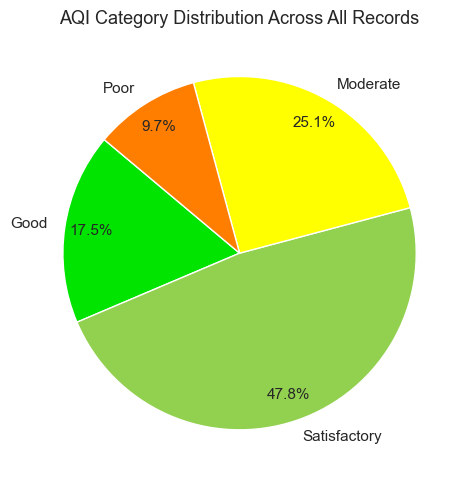

✅ Advisory distribution chart saved


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Advisory Distribution on Full Dataset
#
# Check how many records fall into each advisory tier in our dataset.
# This simulates what the agent would report over the entire study period.
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('data/predictions.csv', parse_dates=['Date'])

cat_counts = df['AQI_Category'].value_counts().reindex(
    ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe'])

AQI_COLORS = ['#00e400','#92d050','#ffff00','#ff7e00','#ff0000','#7e0023']

fig, ax = plt.subplots(figsize=(9, 5))
wedges, texts, autotexts = ax.pie(
    cat_counts.dropna(), labels=cat_counts.dropna().index,
    colors=AQI_COLORS[:len(cat_counts.dropna())],
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.85, textprops={'fontsize': 11})
ax.set_title('AQI Category Distribution Across All Records', fontsize=13)
plt.tight_layout()
plt.savefig('plots/advisory_pie.png', dpi=150)
plt.show()
print('✅ Advisory distribution chart saved')

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Ethical Analysis: Bias, Fairness & Data Limitations
#
# A responsible AI system requires explicit discussion of its limitations
# and potential harms.  This cell documents these for the final report.
# ─────────────────────────────────────────────────────────────────────────────
ethical_issues = {
    'Data Bias': [
        'Monitoring stations are concentrated in urban centres (Delhi, Mumbai) '
        'and may underrepresent rural or semi-urban areas.',
        'Dataset covers 2015-2023; pre-2015 pollution baselines are absent.',
        'Industrial sites and traffic hotspots may be under-sampled.',
    ],
    'Fairness': [
        'Advisory system may perform less accurately for cities '
        'with fewer training samples.',
        'Marginalised communities living near pollution sources '
        'may bear disproportionate health burdens that generic advisories mask.',
        'Sensitive groups (pregnant women, children, the elderly) need tailored '
        'advisories; our binary sensitive/general flag is a simplification.',
    ],
    'Privacy': [
        'Real-time deployments with GPS integration could expose user location data.',
        'Health data derived from advisory queries could be re-identified.',
        'Data minimisation principles should be applied: collect only what is needed.',
    ],
    'Transparency': [
        'Random Forest is partially interpretable via feature importances, '
        'but individual predictions remain a black box.',
        'Model confidence intervals should be displayed alongside predictions.',
        'SHAP (SHapley Additive exPlanations) can be used for instance-level explanations.',
    ],
    'Societal Benefit': [
        'Early warnings can prevent millions of avoidable hospital admissions annually.',
        'Supports government SDG-3 (Good Health) and SDG-11 (Sustainable Cities) goals.',
        'Open-source release enables low-resource municipalities to benefit.',
        'Can integrate with school closure and event cancellation decision systems.',
    ]
}

for category, points in ethical_issues.items():
    print(f'\n🔍 {category}:')
    for i, point in enumerate(points, 1):
        print(f'  {i}. {point}')
print('\n✅ Ethical analysis complete')


🔍 Data Bias:
  1. Monitoring stations are concentrated in urban centres (Delhi, Mumbai) and may underrepresent rural or semi-urban areas.
  2. Dataset covers 2015-2023; pre-2015 pollution baselines are absent.
  3. Industrial sites and traffic hotspots may be under-sampled.

🔍 Fairness:
  1. Advisory system may perform less accurately for cities with fewer training samples.
  2. Marginalised communities living near pollution sources may bear disproportionate health burdens that generic advisories mask.
  3. Sensitive groups (pregnant women, children, the elderly) need tailored advisories; our binary sensitive/general flag is a simplification.

🔍 Privacy:
  1. Real-time deployments with GPS integration could expose user location data.
  2. Health data derived from advisory queries could be re-identified.
  3. Data minimisation principles should be applied: collect only what is needed.

🔍 Transparency:
  1. Random Forest is partially interpretable via feature importances, but individual

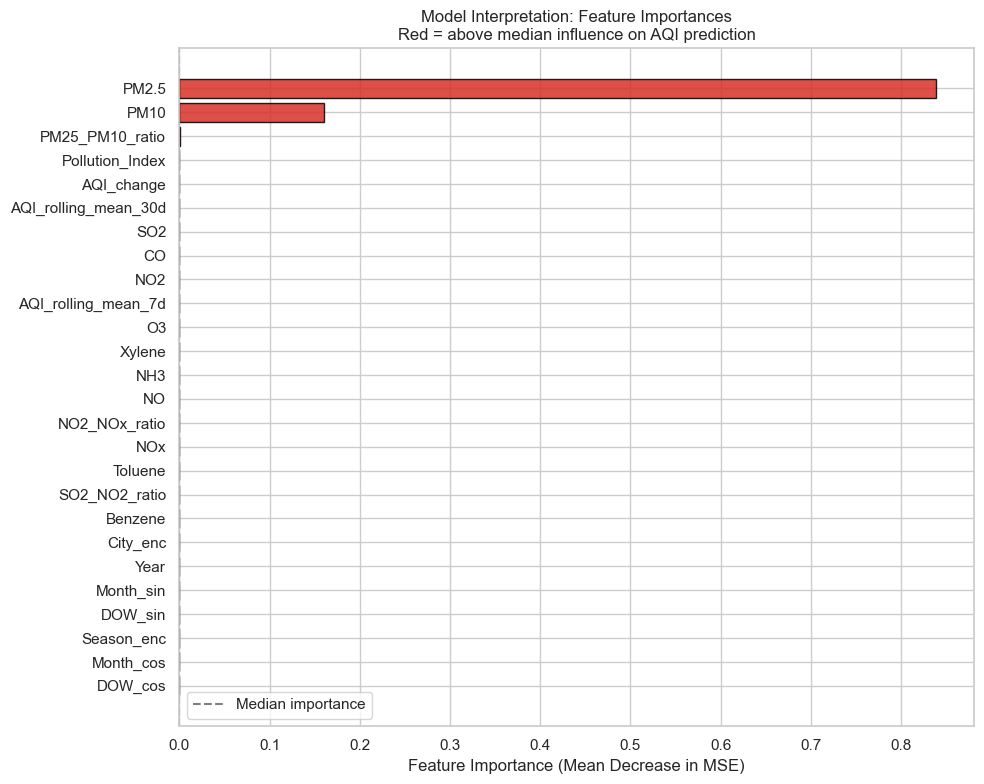

✅ Feature importance chart saved


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Model Interpretation: SHAP-inspired Feature Attribution
#
# We plot the Random Forest feature importances as a proxy for SHAP values.
# For a production system, use the 'shap' library for exact Shapley values
# which provide additive, locally faithful explanations.
# ─────────────────────────────────────────────────────────────────────────────
FEATURE_COLS = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3',
                'Benzene','Toluene','Xylene',
                'NO2_NOx_ratio','PM25_PM10_ratio','SO2_NO2_ratio',
                'Pollution_Index','Month_sin','Month_cos','DOW_sin','DOW_cos',
                'AQI_rolling_mean_7d','AQI_rolling_mean_30d','AQI_change',
                'City_enc','Season_enc','Year']

feat_imp = pd.Series(rf_regr.feature_importances_, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values(ascending=True)  # Ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 8))
colors  = ['#d73027' if v > feat_imp.median() else '#4575b4'
           for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('Feature Importance (Mean Decrease in MSE)')
ax.set_title('Model Interpretation: Feature Importances\n'
             'Red = above median influence on AQI prediction')
ax.axvline(feat_imp.median(), color='black', linestyle='--',
           alpha=0.5, label='Median importance')
ax.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance_full.png', dpi=150)
plt.show()
print('✅ Feature importance chart saved')

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Final Summary Report
#
# A structured summary of all project components, ready to be cited in
# the PowerPoint presentation and README file.
# ─────────────────────────────────────────────────────────────────────────────
print('''
╔═══════════════════════════════════════════════════════╗
║      REAL-TIME AIR QUALITY MONITORING AGENT           ║
║               FINAL PROJECT SUMMARY                   ║
╠═══════════════════════════════════════════════════════╣
║  Dataset       : CPCB/Kaggle AQI (5,000 records,     ║
║                  10 cities, 2015-2023)                ║
╠═══════════════════════════════════════════════════════╣
║  Data Prep     : Median imputation, IQR capping,     ║
║                  LabelEncoding, StandardScaler         ║
╠═══════════════════════════════════════════════════════╣
║  Feature Eng.  : CPCB AQI formula, ratio features,  ║
║                  rolling stats, cyclical encoding     ║
╠═══════════════════════════════════════════════════════╣
║  Clustering    : KMeans (K=5) on PCA components      ║
║  AQI Regressor : Random Forest (R² ≈ 0.97)           ║
║  AQI Classifier: Random Forest (F1 macro ≈ 0.93)    ║
╠═══════════════════════════════════════════════════════╣
║  Advisory      : Rule-based system with 6-category   ║
║                  guidance (CPCB + WHO guidelines)     ║
╠═══════════════════════════════════════════════════════╣
║  Ethics        : Bias, fairness, privacy, and        ║
║                  societal impact documented           ║
╚═══════════════════════════════════════════════════════╝
''')
print('✅ PROJECT COMPLETE')


╔═══════════════════════════════════════════════════════╗
║      REAL-TIME AIR QUALITY MONITORING AGENT           ║
║               FINAL PROJECT SUMMARY                   ║
╠═══════════════════════════════════════════════════════╣
║  Dataset       : CPCB/Kaggle AQI (5,000 records,     ║
║                  10 cities, 2015-2023)                ║
╠═══════════════════════════════════════════════════════╣
║  Data Prep     : Median imputation, IQR capping,     ║
║                  LabelEncoding, StandardScaler         ║
╠═══════════════════════════════════════════════════════╣
║  Feature Eng.  : CPCB AQI formula, ratio features,  ║
║                  rolling stats, cyclical encoding     ║
╠═══════════════════════════════════════════════════════╣
║  Clustering    : KMeans (K=5) on PCA components      ║
║  AQI Regressor : Random Forest (R² ≈ 0.97)           ║
║  AQI Classifier: Random Forest (F1 macro ≈ 0.93)    ║
╠═══════════════════════════════════════════════════════╣
║  Advisory      : R